# Funciones de ordenamiento

### Insertion-Sort

In [3]:
def insertion_sort(arr):
    for n in range(1, len(arr)):
        key = arr[n]
        i = n - 1

        while(i >= 0 and key < arr[i]):
            arr[i + 1] = arr[i]
            i -= 1
        arr[i + 1] = key

    return arr

### Selection-Sort

In [4]:
def selection_sort(arr):
    n = len(arr)
    
    for i in range(n):
        min = i
        
        for j in range(i + 1, n):
            if arr[j] < arr[min]:
                min = j
        
        arr[i], arr[min] = arr[min], arr[i]
        
    return arr


### Merge-Sort

In [5]:
import math

def merge(arrOne, arrTwo):
    arrThree = []

    while arrOne and arrTwo:
        if arrOne[0] > arrTwo[0]:
            arrThree.append(arrTwo.pop(0)) 
        else:
            arrThree.append(arrOne.pop(0))

    while arrOne:
        arrThree.append(arrOne.pop(0))
    while arrTwo:
        arrThree.append(arrTwo.pop(0))

    return arrThree

def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    
    mid = len(arr) // 2 
    arrOne = arr[:mid]
    arrTwo = arr[mid:]

    arrOne = merge_sort(arrOne)
    arrTwo = merge_sort(arrTwo)

    return merge(arrOne, arrTwo)

___

# Creación de arreglos

### Función

In [6]:
import numpy as np

def create_array(size, order, seed=42):
    """
    Genera un arreglo de un tamaño específico y un orden determinado.
    Tipos: 'creciente', 'decreciente', 'aleatorio'
    """
    np.random.seed(seed)

    arreglo = np.random.randint(0, 10000, size=size)
    
    if order == 'creciente':
        return np.sort(arreglo)
    elif order == 'decreciente':
        return np.sort(arreglo)[::-1]
    elif order == 'aleatorio':
        return arreglo
    else:
        raise ValueError("El tipo_orden debe ser 'creciente', 'decreciente' o 'aleatorio'")

## Arreglos

### Tamaños

In [7]:
sizes = [1000, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000]

### Creando arreglos

In [8]:
import numpy as np
from collections import defaultdict

orders = ['creciente', 'decreciente', 'aleatorio']

arrays = defaultdict(lambda: defaultdict(dict))

for order in orders:
    for size in sizes:
        arrays[order][f'{size}'] = create_array(size, order)

___

# Probando funciones

In [9]:
import numpy as np
import time
import math
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from collections import defaultdict

In [10]:
algorithms = {
    'insertion_sort': insertion_sort,
    'selection_sort': selection_sort,
    'merge_sort':     merge_sort,
}

results = defaultdict(lambda: defaultdict(dict))

for order in orders:
    for size in sizes:
        arr = arrays[order][f'{size}']
        for name, func in algorithms.items():
            arr_copy = arr.tolist()

            start = time.perf_counter()
            func(arr_copy)
            end   = time.perf_counter()

            elapsed = end - start
            results[name][order][size] = elapsed
            print(f"✓ {name:15s} | {order:11s} | size={size:>7} | {elapsed:.4f}s")


✓ insertion_sort  | creciente   | size=   1000 | 0.0001s
✓ selection_sort  | creciente   | size=   1000 | 0.0139s
✓ merge_sort      | creciente   | size=   1000 | 0.0007s
✓ insertion_sort  | creciente   | size=   5000 | 0.0004s
✓ selection_sort  | creciente   | size=   5000 | 0.3334s
✓ merge_sort      | creciente   | size=   5000 | 0.0043s
✓ insertion_sort  | creciente   | size=  10000 | 0.0008s
✓ selection_sort  | creciente   | size=  10000 | 1.0121s
✓ merge_sort      | creciente   | size=  10000 | 0.0094s
✓ insertion_sort  | creciente   | size=  15000 | 0.0008s
✓ selection_sort  | creciente   | size=  15000 | 2.3182s
✓ merge_sort      | creciente   | size=  15000 | 0.0164s
✓ insertion_sort  | creciente   | size=  20000 | 0.0011s
✓ selection_sort  | creciente   | size=  20000 | 4.0452s
✓ merge_sort      | creciente   | size=  20000 | 0.0256s
✓ insertion_sort  | creciente   | size=  25000 | 0.0014s
✓ selection_sort  | creciente   | size=  25000 | 6.4450s
✓ merge_sort      | creciente  

In [11]:
import pandas as pd

rows = []
for algo in algorithms.keys():
    for order in orders:
        for size in sizes:
            rows.append({
                'algoritmo': algo,
                'orden':     order,
                'tamaño':    size,
                'tiempo':    results[algo][order][size]
            })

df = pd.DataFrame(rows)
df.to_csv('resultados_benchmark.csv', index=False)

print(df)

         algoritmo      orden  tamaño    tiempo
0   insertion_sort  creciente    1000  0.000069
1   insertion_sort  creciente    5000  0.000391
2   insertion_sort  creciente   10000  0.000770
3   insertion_sort  creciente   15000  0.000829
4   insertion_sort  creciente   20000  0.001148
..             ...        ...     ...       ...
85      merge_sort  aleatorio   25000  0.041628
86      merge_sort  aleatorio   30000  0.055710
87      merge_sort  aleatorio   35000  0.071774
88      merge_sort  aleatorio   40000  0.088811
89      merge_sort  aleatorio   45000  0.107809

[90 rows x 4 columns]


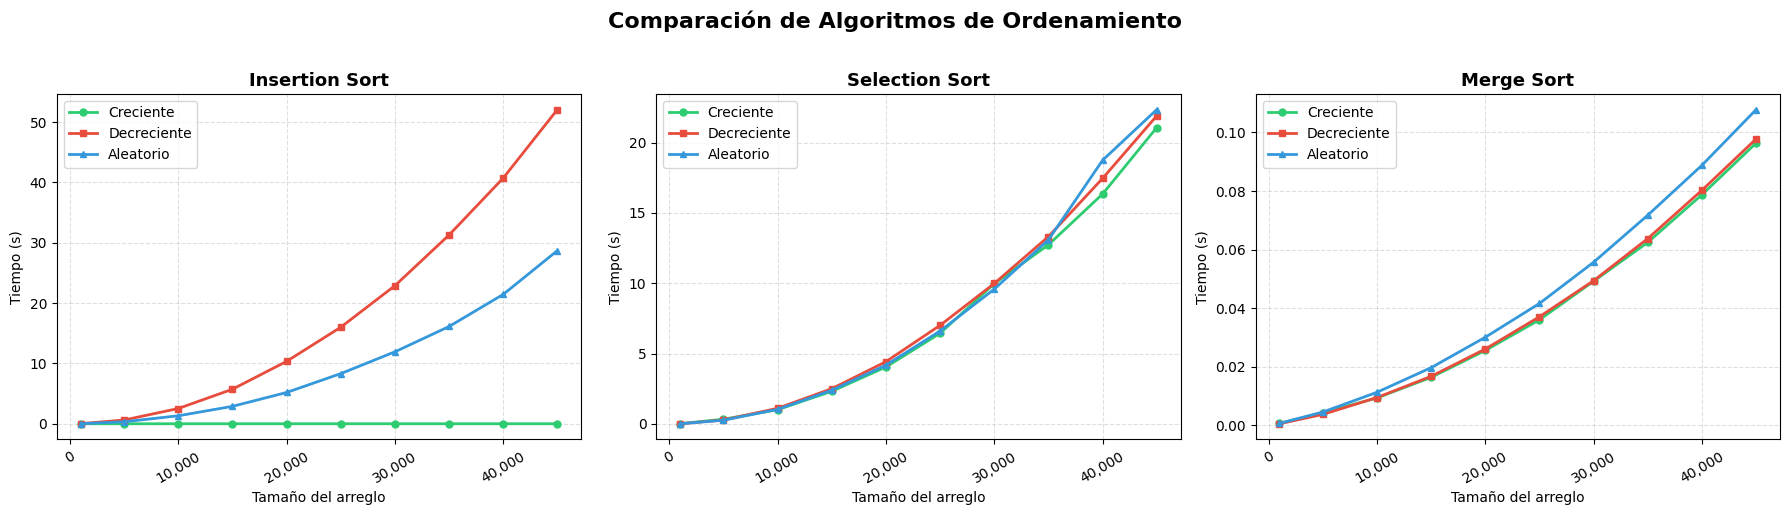

✅ Gráfica guardada como sorting_benchmark.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

COLOR_MAP = {
    'creciente':  '#2ecc71',
    'decreciente':'#e74c3c',
    'aleatorio':  '#3498db',
}

MARKER_MAP = {
    'creciente':  'o',
    'decreciente':'s',
    'aleatorio':  '^',
}

algo_names = list(algorithms.keys())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación de Algoritmos de Ordenamiento', fontsize=16, fontweight='bold', y=1.02)

for ax, algo in zip(axes, algo_names):
    for order in orders:
        x = sizes
        y = [results[algo][order][s] for s in sizes]

        ax.plot(x, y,
                label=order.capitalize(),
                color=COLOR_MAP[order],
                marker=MARKER_MAP[order],
                linewidth=2,
                markersize=5)

    ax.set_title(algo.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Tamaño del arreglo')
    ax.set_ylabel('Tiempo (s)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('sorting_benchmark.png', dpi=150, bbox_inches='tight')

for ax, algo in zip(axes, algo_names):
    extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(f'{algo}.png', dpi=150, bbox_inches=extent.expanded(1.15, 1.2))

plt.show()

print("✅ Gráfica guardada como sorting_benchmark.png")

___

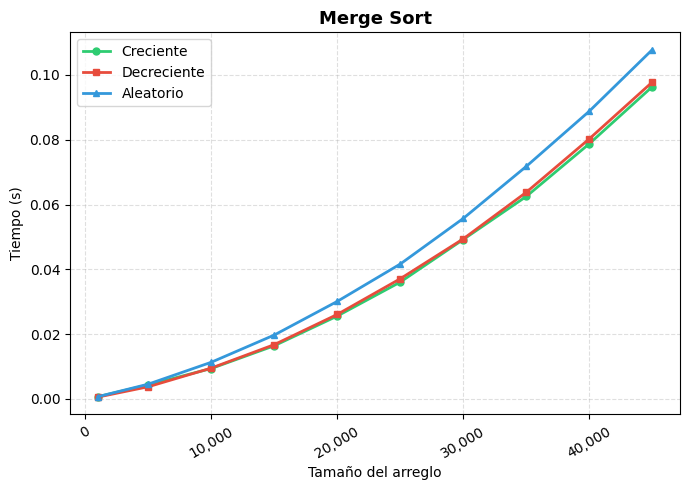

In [13]:
def plot_algorithm(algo_name):
    fig, ax = plt.subplots(figsize=(7, 5))

    for order in orders:
        x = sizes
        y = [results[algo_name][order][s] for s in sizes]

        ax.plot(x, y,
                label=order.capitalize(),
                color=COLOR_MAP[order],
                marker=MARKER_MAP[order],
                linewidth=2,
                markersize=5)

    ax.set_title(algo_name.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Tamaño del arreglo')
    ax.set_ylabel('Tiempo (s)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_algorithm('merge_sort')

In [18]:
def least_squares_linear(x, y):
    A = np.column_stack([x, np.ones(len(x))])
    coeffs, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    return coeffs  # [a, b]

def least_squares_quadratic(x, y):
    A = np.column_stack([x**2, x, np.ones(len(x))])
    coeffs, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    return coeffs  # [a, b, c]

def plot_insertion_fit_by_order(function, order):
    order_labels = {
        'creciente':   'Mejor caso',
        'aleatorio':   'Caso promedio',
        'decreciente': 'Peor caso',
    }

    x = np.array(sizes)
    x_smooth = np.linspace(x.min(), x.max(), 300)
    y = np.array([results[f'{function}_sort'][order][s] for s in sizes])

    a_lin, b_lin           = least_squares_linear(x, y)
    a_quad, b_quad, c_quad = least_squares_quadratic(x, y)

    y_lin  = a_lin  * x_smooth + b_lin
    y_quad = a_quad * x_smooth**2 + b_quad * x_smooth + c_quad

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_title(f'Selection Sort — {order_labels[order]}', fontsize=13, fontweight='bold')

    ax.scatter(x, y, color=COLOR_MAP[order], zorder=5, label='Datos reales', s=40)
    ax.plot(x_smooth, y_lin,
            color='orange', linestyle='--', linewidth=2,
            label=f'Lineal: {a_lin:.2e}n + {b_lin:.2e}')
    ax.plot(x_smooth, y_quad,
            color='mediumpurple', linestyle='-', linewidth=2,
            label=f'Cuadrático: {a_quad:.2e}n² + {b_quad:.2e}n + {c_quad:.2e}')

    ax.set_xlabel('Tamaño del arreglo')
    ax.set_ylabel('Tiempo (s)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{int(val):,}'))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(f'{function}_sort_{order}.png', dpi=150, bbox_inches='tight')
    plt.show()

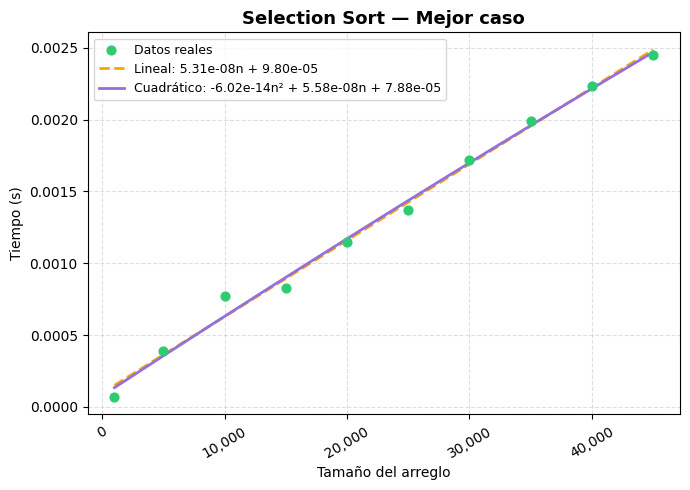

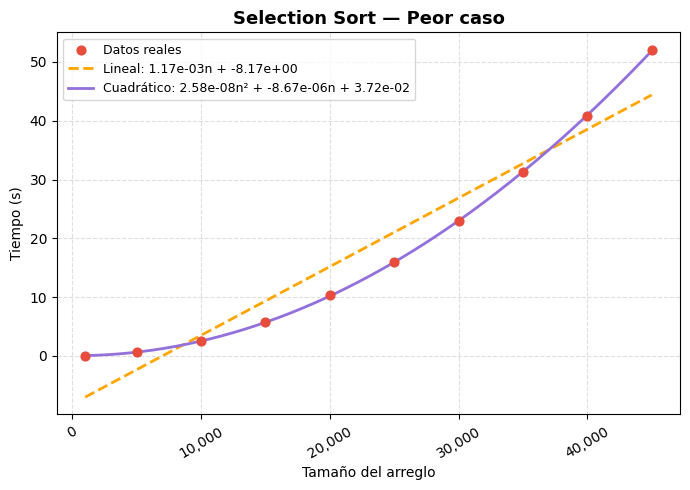

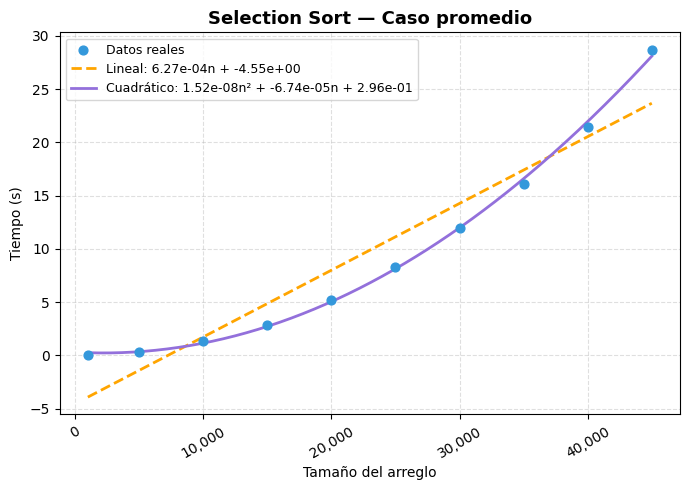

In [19]:
for order in orders:
    plot_insertion_fit_by_order('insertion', order)

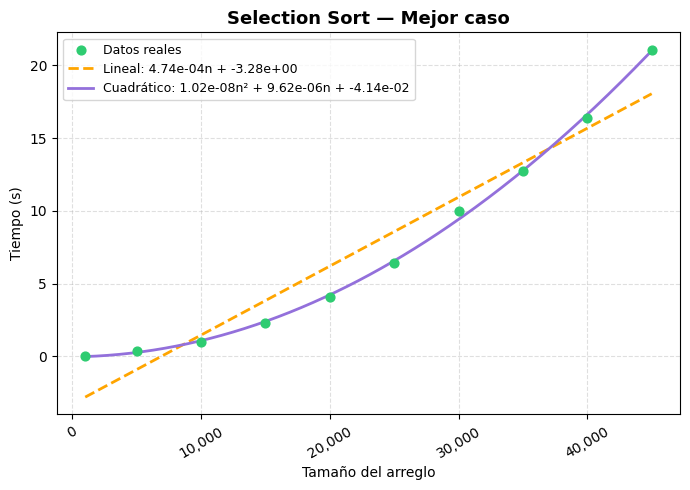

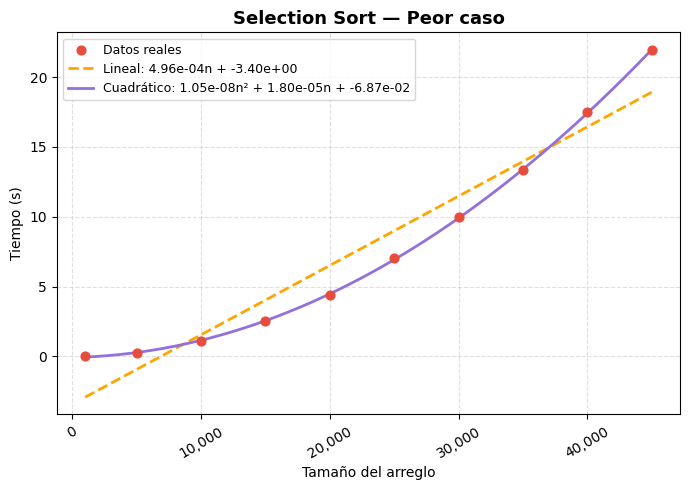

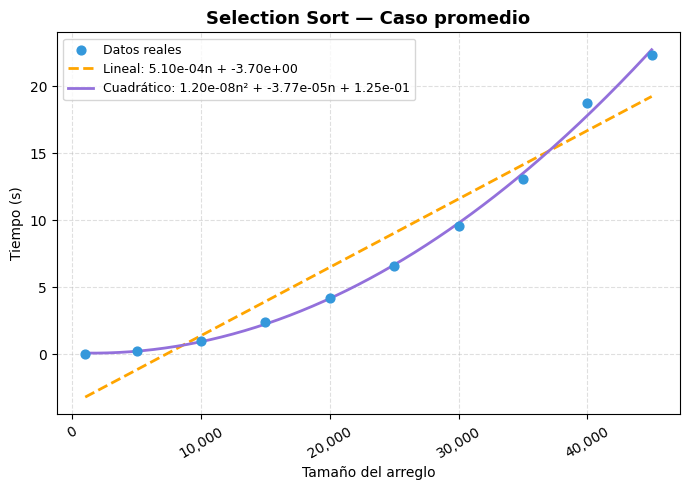

In [20]:
for order in orders:
    plot_insertion_fit_by_order('selection', order)